## **Project Overview**

**Dataset:** [Mall Customers Dataset](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?datasetId=42674)

Customer segmentation is one of the most common applications of unsupervised learning in marketing and retail. Different customers have different spending patterns, and identifying these groups can help businesses better understand their target audience.

In this project, I explored the Mall Customers dataset to identify distinct customer segments based on their annual income and spending behaviour. Since the dataset does not contain predefined labels, clustering techniques were used to uncover natural groupings within the data.

Two clustering algorithms were implemented and compared:

- K-Means Clustering
- Hierarchical Clustering

To determine an appropriate number of clusters, I used the following evaluation techniques:

- Elbow Method
- Silhouette Score
- Dendrogram Analysis

Feature scaling was performed before model training. StandardScaler was used for K-Means clustering, while MinMaxScaler was applied for Hierarchical Clustering.

The final clusters were analysed and visualised using a variety of plots, including bar charts, pie charts, and treemaps, to better understand the characteristics of each customer group.

# Importing and Loading the Dataset

In [1]:
## Load the relevant libraries

import numpy as np                
import pandas as pd               
import matplotlib.pyplot as plt   
import seaborn as sns             
%matplotlib inline
import squarify                   ## for treemaps

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

import warnings                    ## Filter warnings
warnings.filterwarnings('ignore')

In [2]:
## Load the dataset into the environment

df = pd.read_csv('../data/Mall_Customers.csv')

## Check a few records in the dataset that we just loaded

print(df.head(5))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# Exploratory Data Analysis

In [3]:
## quick look at how big this dataset is

print(f'rows : {df.shape[0]}')
print(f'cols : {df.shape[1]}')

rows : 200
cols : 5


In [4]:
print(f'duplicates : {df.duplicated().sum()}')
print(f'missing vals : {sum(df.isna().sum())}')

duplicates : 0
missing vals : 0


- Our dataset is clean. It has **no duplicate values** and **no missing values**. 

In [5]:
## dtypes + summary stats together

print(df.info())
print('--'*50)
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
----------------------------------------------------------------------------------------------------
        CustomerID  Gender         Age  Annual Income (k$)  \
count   200.000000     200  200.000000          200.000000   
unique         NaN       2         NaN                 NaN   
top            NaN  Female         NaN                 NaN   
freq           NaN     112         NaN                 NaN   
mean    100.500000     NaN   38.850000           60.560000   
std      57.879185     NaN

In [6]:
## the column names are a bit long, renaming them
df.rename(columns = {'Annual Income (k$)' : 'Income(k$/yr)', 'Spending Score (1-100)' : 'SpendScore(1-100)'}, inplace=True)

## CustomerID doesn't add anything for clustering so dropping it
df = df.drop(columns=['CustomerID'])

## Check the column names
print(df.columns)  

Index(['Gender', 'Age', 'Income(k$/yr)', 'SpendScore(1-100)'], dtype='str')


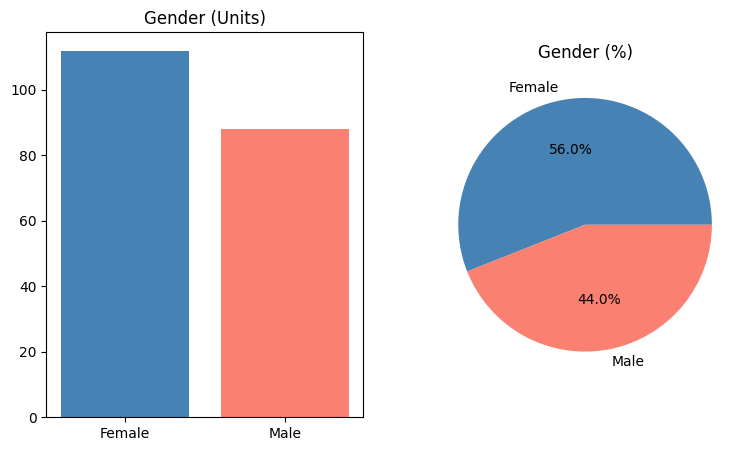

In [7]:
## checking gender split (count and % side by side)

gender_counts = df['Gender'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Bar chart
ax1.bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'])
ax1.set_title('Gender (Units)')

# Pie chart
ax2.pie(gender_counts.values, labels=gender_counts.index, colors=['steelblue', 'salmon'], autopct='%1.1f%%')
ax2.set_title('Gender (%)')

plt.show()
plt.show()

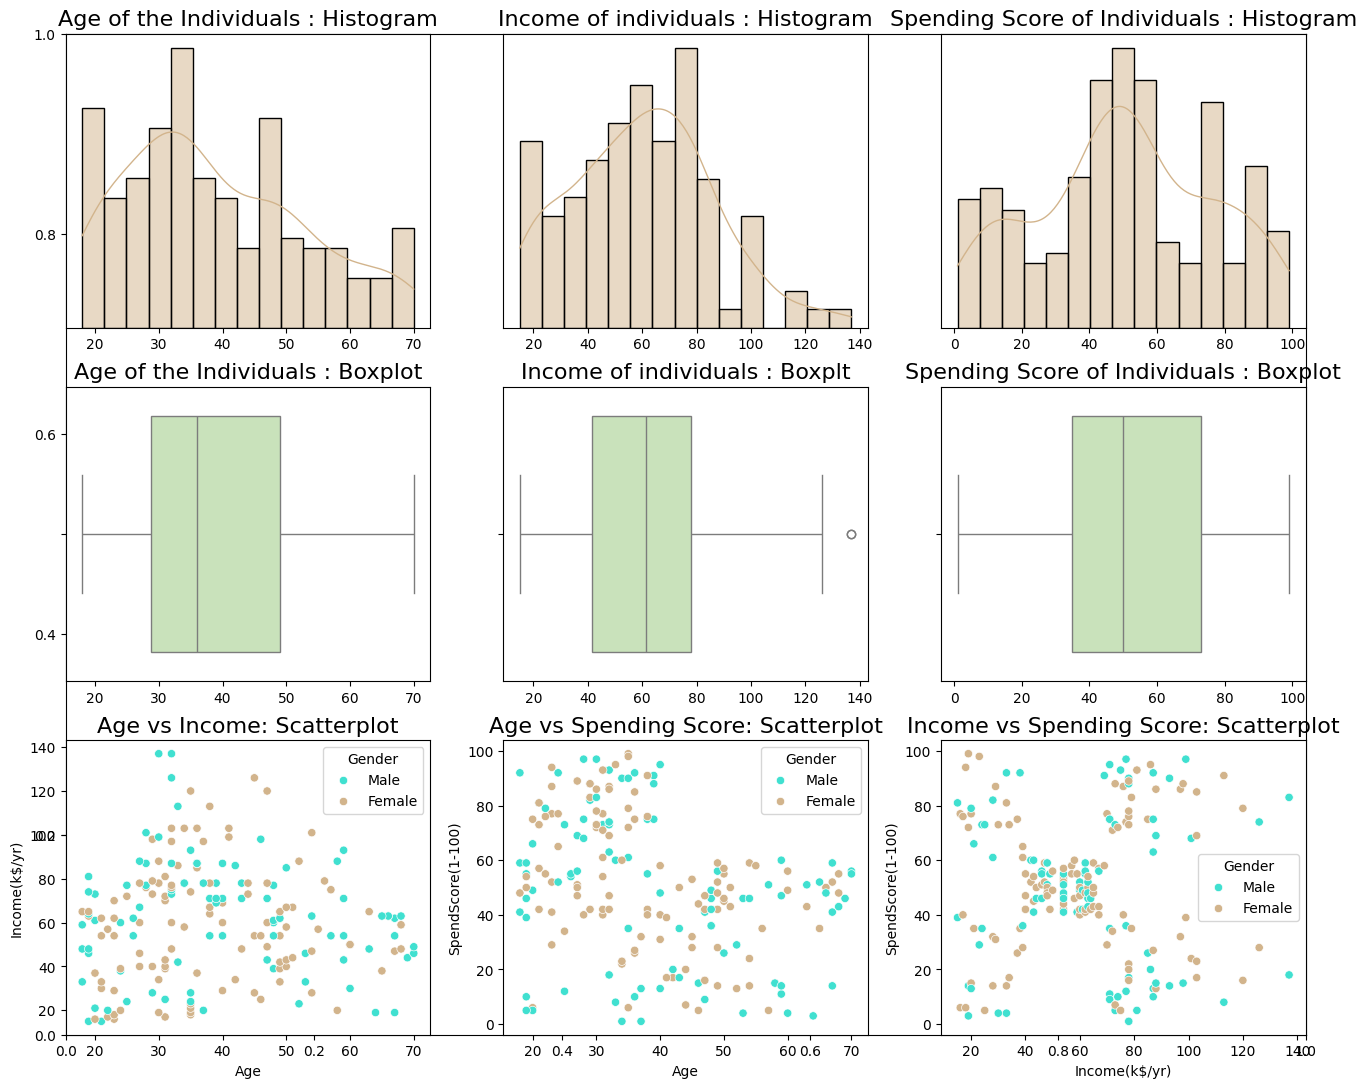

In [8]:
## distributions + boxplots + scatter for all 3 numerical features
## doing it in one grid so I can see everything at once

plt.subplots(figsize=(16,13))

plt.subplot(3,3,1)
plt.title('Age of the Individuals : Histogram', fontsize=16)
sns.histplot(df['Age'], color='#D2B48C', bins=15, kde=True, line_kws={'linewidth':1,'color':'r'})
plt.ylabel(None)
plt.yticks([])
plt.xlabel(None)

plt.subplot(3,3,2)
plt.title('Income of individuals : Histogram', fontsize=16)
sns.histplot(df['Income(k$/yr)'], color='#D2B48C', bins=15, kde=True, line_kws={'linewidth':1,'color':'r'})
plt.ylabel(None)
plt.yticks([])
plt.xlabel(None)

plt.subplot(3,3,3)
plt.title('Spending Score of Individuals : Histogram', fontsize=16)
sns.histplot(df['SpendScore(1-100)'], color='#D2B48C', bins=15, kde=True, line_kws={'linewidth':1,'color':'r'})
plt.ylabel(None)
plt.yticks([])
plt.xlabel(None)

plt.subplot(3,3,4)
plt.title('Age of the Individuals : Boxplot', fontsize=16)
sns.boxplot(df['Age'], color='#c7e9b4', orient="h")
plt.xlabel(None)
plt.ylabel(None)

plt.subplot(3,3,5)
plt.title('Income of individuals : Boxplt', fontsize=16)
sns.boxplot(df['Income(k$/yr)'], color='#c7e9b4', orient="h")
plt.xlabel(None)
plt.ylabel(None)

plt.subplot(3,3,6)
plt.title('Spending Score of Individuals : Boxplot', fontsize=16)
sns.boxplot(df['SpendScore(1-100)'], color='#c7e9b4', orient="h")
plt.xlabel(None)
plt.ylabel(None)

plt.subplot(3,3,7)
plt.title('Age vs Income: Scatterplot', fontsize=16)
sns.scatterplot(data=df, x='Age', y='Income(k$/yr)', hue='Gender', palette=('#40E0D0', '#D2B48C'), alpha=1)

plt.subplot(3,3,8)
plt.title('Age vs Spending Score: Scatterplot', fontsize=16)
sns.scatterplot(data=df, x='Age', y='SpendScore(1-100)', hue='Gender',  palette=('#40E0D0', '#D2B48C'), alpha=1)

plt.subplot(3,3,9)
plt.title('Income vs Spending Score: Scatterplot', fontsize=16)
sns.scatterplot(data=df, x='Income(k$/yr)', y='SpendScore(1-100)', hue='Gender',  palette=('#40E0D0', '#D2B48C'), alpha=1)

plt.show()

- Age feature appears to be a little right skewed, as below 40 age records are more in the dataset.

## Outlier Decision

Some customers have unusually high incomes and appear as outliers. These records were kept because they represent real customers, not errors. Removing them could hide valuable customer segments. StandardScaler was used to reduce the influence of these extreme values during clustering.

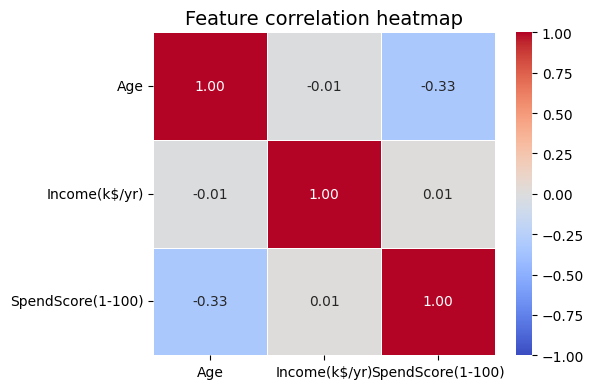

In [9]:
## want to see if any features are correlated before clustering

plt.figure(figsize=(6,4))
plt.title('Feature correlation heatmap', fontsize=14)
sns.heatmap(df[['Age','Income(k$/yr)','SpendScore(1-100)']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

- Income and SpendScore are independent dimensions

In [10]:
## using only Income & SpendScore for clustering
## Age had weak correlation with both, so leaving it out

X = df[['Income(k$/yr)', 'SpendScore(1-100)']].copy()
print(X.head(5))

   Income(k$/yr)  SpendScore(1-100)
0             15                 39
1             15                 81
2             16                  6
3             16                 77
4             17                 40


# KMeans

In [11]:
## scaling before KMeans it's distance based so this matters

scaler = StandardScaler()
X_kmeans =  scaler.fit_transform(X)
print(X_kmeans)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

We use Income and SpendScore as our 2 clustering dimensions because:
- Correlation heatmap showed Age has weak relationship with both
- These 2 axes directly reflect purchasing behaviour and capacity


Scaling:
- StandardScaler for KMeans  → KMeans uses Euclidean distance, which assumes
  zero-mean, unit-variance features. StandardScaler satisfies this.

- MinMaxScaler for Hierarchical → Ward linkage is scale-sensitive but does not
  assume Gaussian distribution; MinMaxScaler keeps proportional distances
  while bounding values to [0,1].

In [12]:
## running kmeans for k = 1 to 10 and storing inertia each time

wcss = []

for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++', random_state = 42)
    kmeans.fit(X_kmeans)
    wcss.append(kmeans.inertia_)

wcss

[399.9999999999999,
 273.6688866264201,
 157.70400815035947,
 109.22822707921347,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.059322694042212]

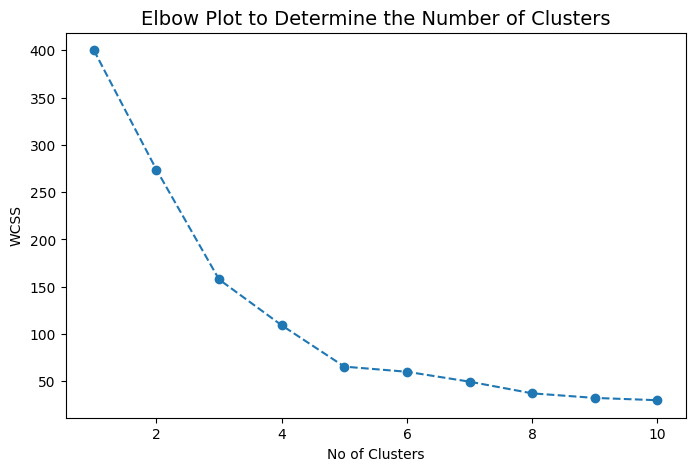

In [13]:
## plotting the elbow looking for where the curve bends

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, 'o--')
plt.title('Elbow Plot to Determine the Number of Clusters', fontsize=14)
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')

plt.show()

In [14]:
from kneed import KneeLocator

In [15]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
print('The Knee located at figure:', kl.elbow)

The Knee located at figure: 5


In [16]:
## cross-checking with silhouette score (can't run it for k=1 so starting at 2)

silhouette_coef = []

for cluster in range(2,11):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++', random_state = 42)
    kmeans.fit(X_kmeans)
    score = silhouette_score(X_kmeans, kmeans.labels_)
    silhouette_coef.append(score)

silhouette_coef

[0.3973270007887498,
 0.46658474419000145,
 0.49434988482196784,
 0.5546571631111091,
 0.5138257534676561,
 0.50200146805547,
 0.4550112502601921,
 0.4566624374485964,
 0.44475993501732874]

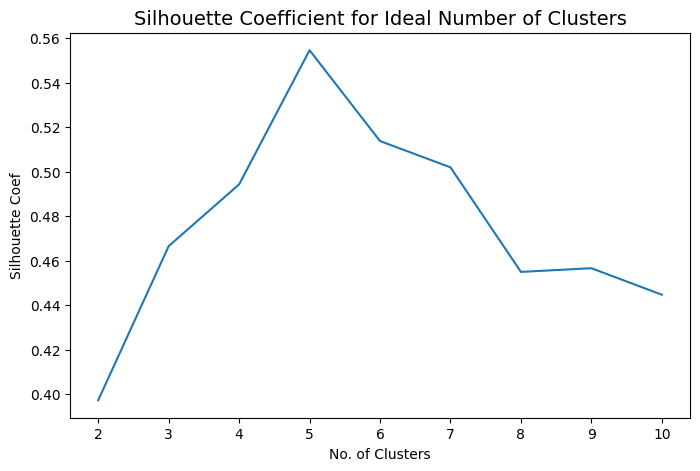

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_coef)
plt.xticks(range(2,11))
plt.title('Silhouette Coefficient for Ideal Number of Clusters', fontsize=14)
plt.xlabel('No. of Clusters')
plt.ylabel('Silhouette Coef')
plt.show()

- From the above silhouette figure, **we can determine 5 as the number of clusters**

- The silhouette score peaks at k=5 (~0.554), which is the highest across all values tested, 
  confirming 5 as the optimal number of clusters. This aligns with the elbow method, 
  giving us strong dual confirmation for this choice.

In [18]:
## going with k=5 based on both elbow + silhouette

KMeans_clusters = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = KMeans_clusters.fit_predict(X_kmeans)
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [19]:
## adding cluster labels back to the original df

df_Kmeans = df.copy()            ## making a copy of original dataframe
df_Kmeans['Cluster'] = y_kmeans  ## appending the cluster column
print(df_Kmeans.head(5))

   Gender  Age  Income(k$/yr)  SpendScore(1-100)  Cluster
0    Male   19             15                 39        4
1    Male   21             15                 81        2
2  Female   20             16                  6        4
3  Female   23             16                 77        2
4  Female   31             17                 40        4


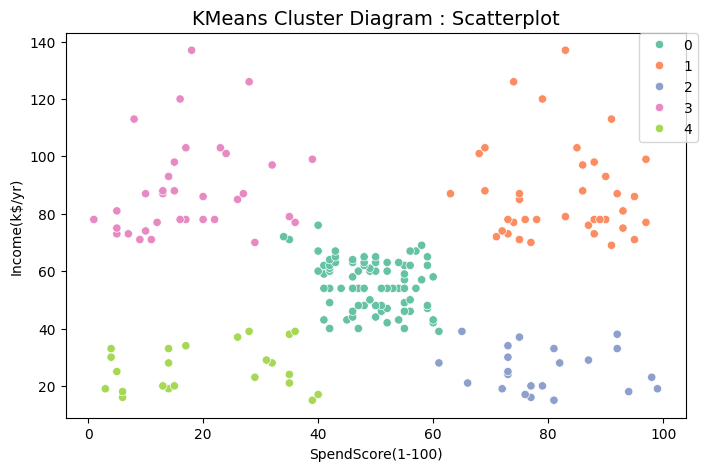

In [20]:
## Visualising the new dataframe with cluster numbers through scatterplot

plt.figure(figsize=(8,5))
plt.title('KMeans Cluster Diagram : Scatterplot', fontsize=14)
sns.scatterplot(data=df_Kmeans, x='SpendScore(1-100)', y='Income(k$/yr)', hue='Cluster', palette="Set2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

# Hierarchial Clustering

In [21]:
## normalising for hierarchical using minmax instead of standard here

norm = MinMaxScaler()

X_Hierar = norm.fit_transform(X)
X_Hierar = pd.DataFrame(X_Hierar, columns=X.columns)
print(X_Hierar.head(5))

   Income(k$/yr)  SpendScore(1-100)
0       0.000000           0.387755
1       0.000000           0.816327
2       0.008197           0.051020
3       0.008197           0.775510
4       0.016393           0.397959


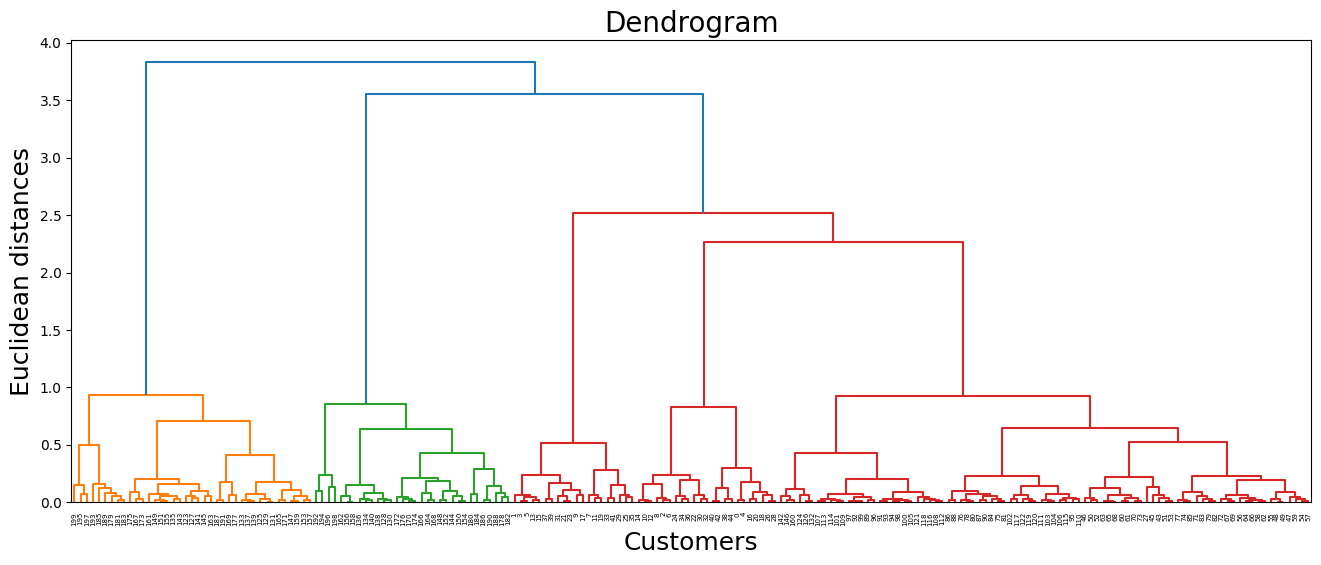

In [22]:
## dendrogram to get a feel for the cluster structure

plt.figure(figsize=(16,6))
dendrogram = shc.dendrogram(shc.linkage(X_Hierar, method = 'ward'))
plt.title('Dendrogram', fontsize=20)
plt.xlabel('Customers', fontsize=18)
plt.ylabel('Euclidean distances', fontsize=18)
plt.show()

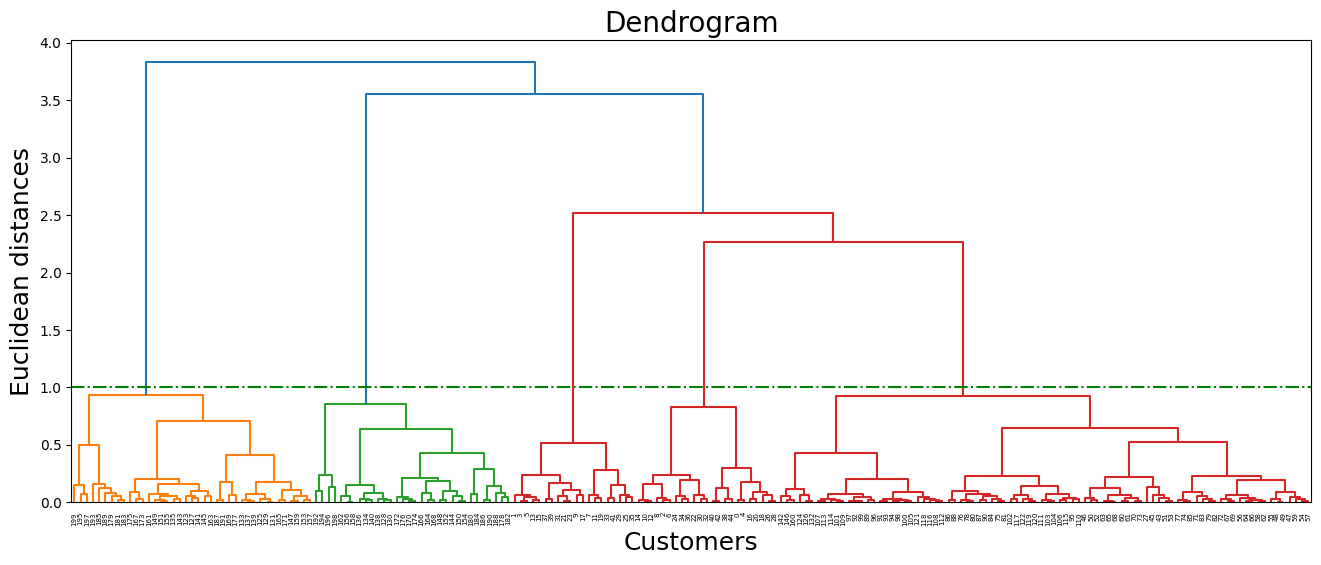

In [23]:
## adding threshold line wherever it cuts the most branches = ideal k

plt.figure(figsize=(16,6))
dendrogram = shc.dendrogram(shc.linkage(X_Hierar, method = 'ward'))
plt.axhline(y = 1, color = 'g', linestyle = 'dashdot')

plt.title('Dendrogram', fontsize=20)
plt.xlabel('Customers', fontsize=18)
plt.ylabel('Euclidean distances', fontsize=18)
plt.show()

- The threshold line **intersects 5 vertical lines**, hence we can conclude that **the number of clusters we can have as 5**.

In [24]:
## dendrogram also says 5, fitting the model

Hierarchial_clusters = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_kmeans = Hierarchial_clusters.fit_predict(X_Hierar)
y_kmeans

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 1, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0])

In [25]:
df_Hierar = df.copy()   ## making a copy of original dataframe
df_Hierar['Cluster'] = y_kmeans  ## appending the cluster column
print(df_Hierar.head(5))

   Gender  Age  Income(k$/yr)  SpendScore(1-100)  Cluster
0    Male   19             15                 39        4
1    Male   21             15                 81        3
2  Female   20             16                  6        4
3  Female   23             16                 77        3
4  Female   31             17                 40        4


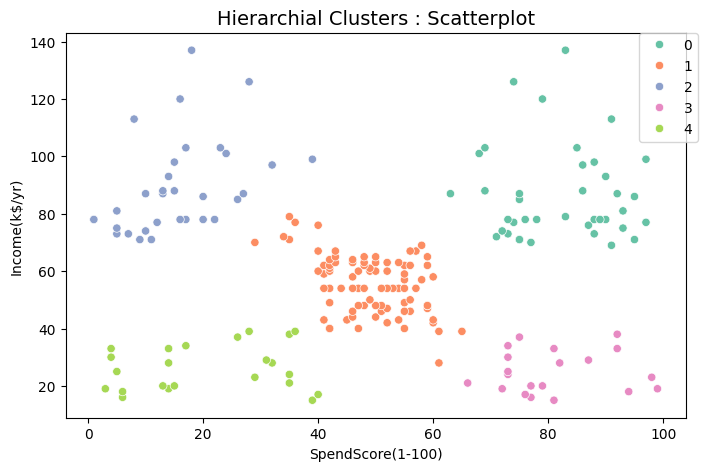

In [26]:
## Visualising the new dataframe with cluster numbers through scatterplot

plt.figure(figsize=(8,5))
plt.title('Hierarchial Clusters : Scatterplot', fontsize=14)
sns.scatterplot(data=df_Hierar, x='SpendScore(1-100)', y='Income(k$/yr)', hue='Cluster', palette="Set2")
plt.legend(bbox_to_anchor=(1.02, 1), loc='best', borderaxespad=0)
plt.show()

# KMeans VS Hierarchial Clustering 

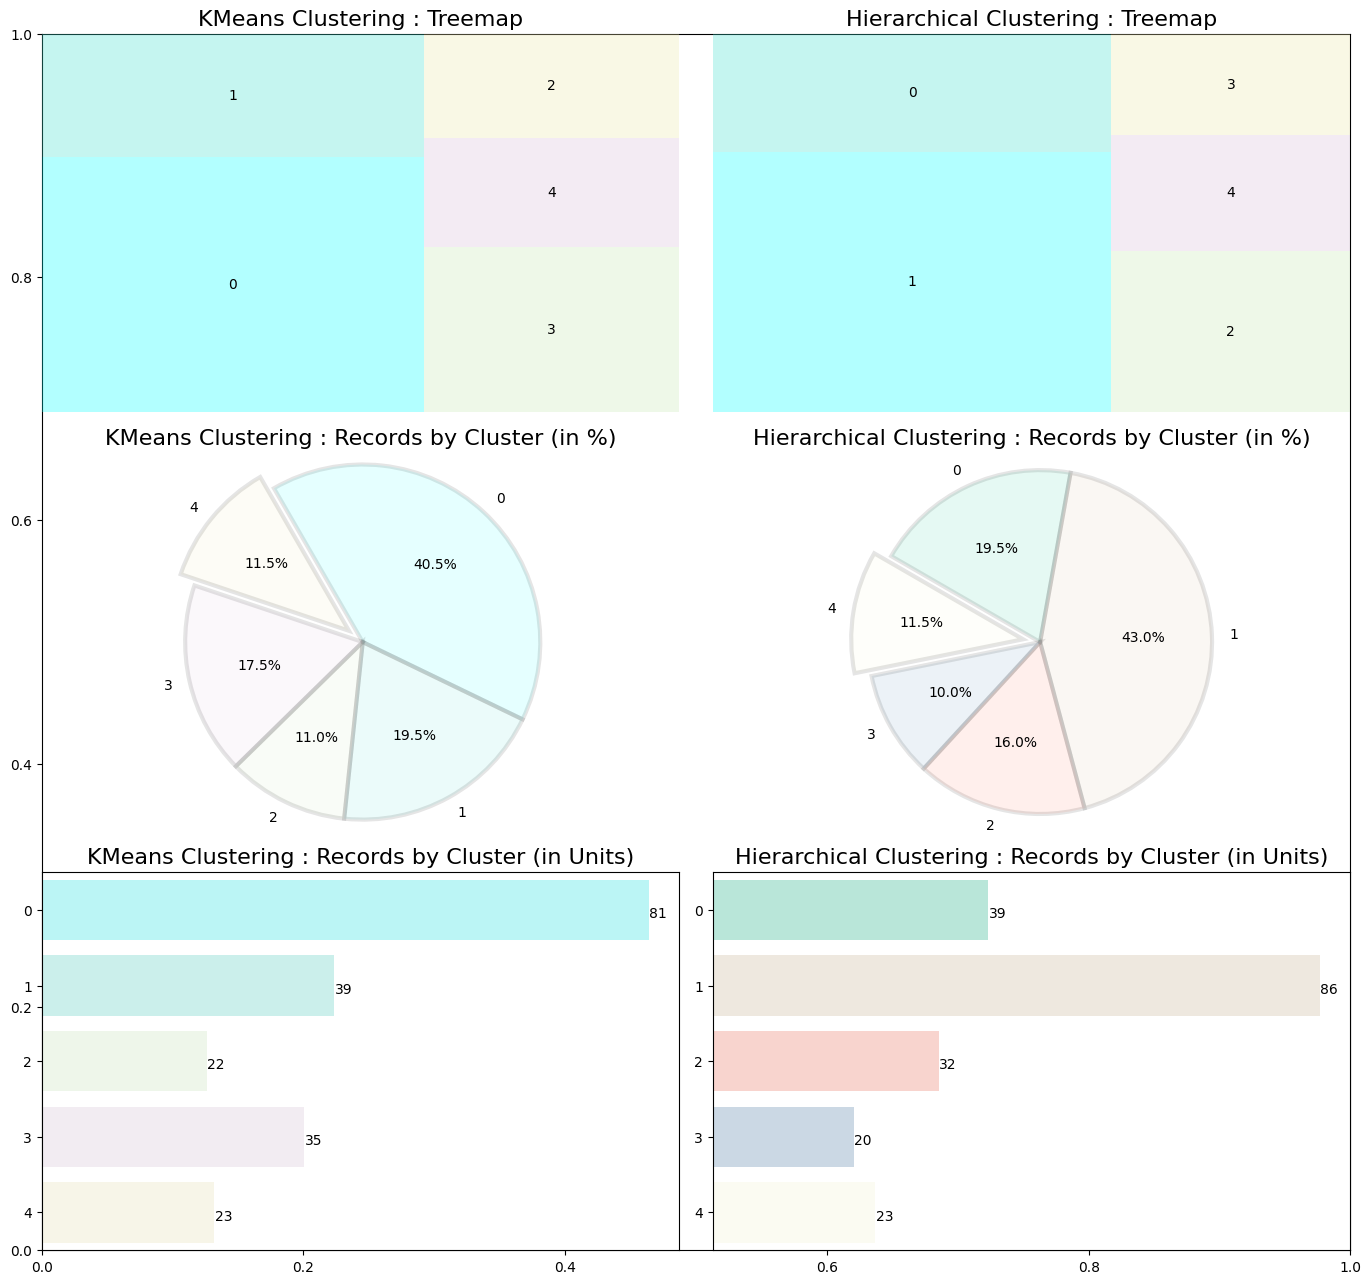

In [27]:
## comparing both models side by side treemaps, pies, bars

plt.subplots(figsize=(14,13))
my_pal = ('#00FFFF','#40E0D0', '#c7e9b4', '#D8BFD8', '#EEE8AA')
my_col = ('#00C78C', '#D2B48C', '#FF6347', '#4682B4','#FAFAD2')

## KMeans clustering
plt.subplot(3,2,1)
plt.title('KMeans Clustering : Treemap', fontsize=16)
labels = df_Kmeans['Cluster'].value_counts().index.get_level_values(0).tolist()
raw_sizes = df_Kmeans['Cluster'].value_counts().reset_index()['count'].values.tolist()
sizes = squarify.normalize_sizes(raw_sizes, 100, 100)
squarify.plot(sizes=sizes, label=labels, color=my_pal, alpha=.3)
plt.axis('off')

## Hierarchical clustering
plt.subplot(3,2,2)
plt.title('Hierarchical Clustering : Treemap', fontsize=16)
labels = df_Hierar['Cluster'].value_counts().index.get_level_values(0).tolist()
raw_sizes = df_Hierar['Cluster'].value_counts().reset_index()['count'].values.tolist()
sizes = squarify.normalize_sizes(raw_sizes, 100, 100)
squarify.plot(sizes=sizes, label=labels, color=my_pal, alpha=.3)
plt.axis('off')

plt.subplot(3,2,3)
my_xpl = [0.0, 0.0, 0.0, 0.0, 0.1]
plt.title('KMeans Clustering : Records by Cluster (in %)', fontsize=16)
sizes = df_Kmeans['Cluster'].value_counts().sort_index() / df_Kmeans['Cluster'].value_counts().sum() * 100
labels = sizes.index
plt.pie(sizes, labels=labels, colors=my_pal, explode=my_xpl, counterclock=False,
        startangle=120, wedgeprops={'alpha':0.1, 'edgecolor':'black','linewidth':3,
        'antialiased':True}, autopct='%1.1f%%')
plt.axis('equal')
plt.tight_layout()

plt.subplot(3,2,4)
my_xpl = [0.0, 0.0, 0.0, 0.0, 0.1]
plt.title('Hierarchical Clustering : Records by Cluster (in %)', fontsize=16)
sizes = df_Hierar['Cluster'].value_counts().sort_index() / df_Hierar['Cluster'].value_counts().sum() * 100
labels = sizes.index
plt.pie(sizes, labels=labels, colors=my_col, explode=my_xpl, counterclock=False,
        startangle=150, wedgeprops={'alpha':0.1, 'edgecolor':'black','linewidth':3,
        'antialiased':True}, autopct='%1.1f%%')
plt.axis('equal')
plt.tight_layout()

plt.subplot(3,2,5)
plt.title('KMeans Clustering : Records by Cluster (in Units)', fontsize=16)
my_ord = [0,1,2,3,4]
ax = sns.countplot(y="Cluster", data=df_Kmeans, palette=my_pal, order=my_ord, alpha=0.3)
for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_width()), (p.get_x() + p.get_width() + 0.05, p.get_y()+0.5))
plt.ylabel(None); plt.xlabel(None); plt.xticks([])

plt.subplot(3,2,6)
plt.title('Hierarchical Clustering : Records by Cluster (in Units)', fontsize=16)
my_ord = [0,1,2,3,4]
ax = sns.countplot(y="Cluster", data=df_Hierar, palette=my_col, order=my_ord, alpha=0.3)
for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_width()), (p.get_x() + p.get_width() + 0.05, p.get_y()+0.5))
plt.ylabel(None); plt.xlabel(None); plt.xticks([])

plt.tight_layout()
plt.show()

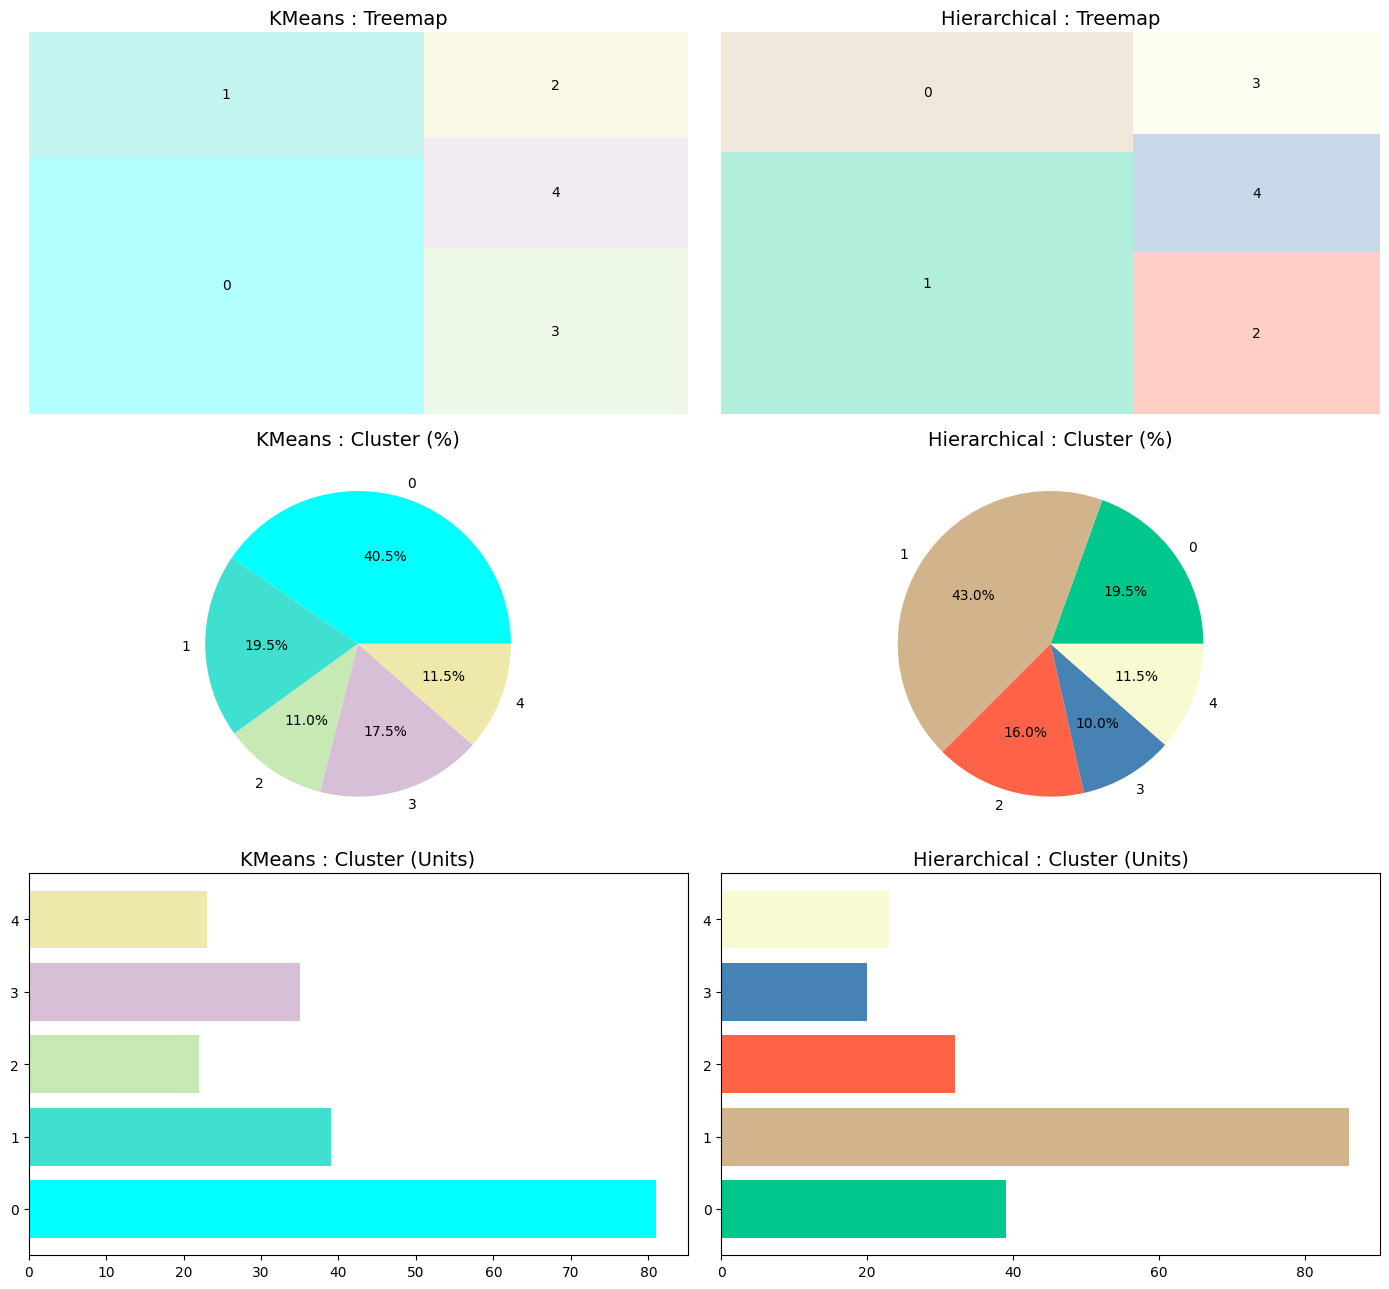

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
c1 = ['#00FFFF', '#40E0D0', '#c7e9b4', '#D8BFD8', '#EEE8AA']
c2 = ['#00C78C', '#D2B48C', '#FF6347', '#4682B4', '#FAFAD2']

## Treemaps
for ax, df, c, title in zip([axes[0,0], axes[0,1]], [df_Kmeans, df_Hierar], [c1, c2],
                             ['KMeans : Treemap', 'Hierarchical : Treemap']):
    counts = df['Cluster'].value_counts()
    plt.sca(ax)
    squarify.plot(sizes=counts.values, label=counts.index, color=c, alpha=0.3)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

## Pie charts
for ax, df, c, title in zip([axes[1,0], axes[1,1]], [df_Kmeans, df_Hierar], [c1, c2],
                             ['KMeans : Cluster (%)', 'Hierarchical : Cluster (%)']):
    counts = df['Cluster'].value_counts().sort_index()
    ax.pie(counts, labels=counts.index, colors=c, autopct='%1.1f%%')
    ax.set_title(title, fontsize=14)

## Bar charts
for ax, df, c, title in zip([axes[2,0], axes[2,1]], [df_Kmeans, df_Hierar], [c1, c2],
                             ['KMeans : Cluster (Units)', 'Hierarchical : Cluster (Units)']):
    counts = df['Cluster'].value_counts().sort_index()
    ax.barh(counts.index.astype(str), counts.values, color=c)
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, calinski_harabasz_score

## ARI - how much do the two cluster assignments actually agree?
ari = adjusted_rand_score(df_Kmeans['Cluster'], df_Hierar['Cluster'])

## DB score - lower = better (tighter, more separated clusters)
db_kmeans = davies_bouldin_score(X_kmeans, df_Kmeans['Cluster'])
db_hierar = davies_bouldin_score(X_Hierar.values, df_Hierar['Cluster'])

## CH score - higher = better
ch_kmeans = calinski_harabasz_score(X_kmeans, df_Kmeans['Cluster'])
ch_hierar = calinski_harabasz_score(X_Hierar.values, df_Hierar['Cluster'])

print("Adjusted Rand Index  :", round(ari, 4))
print()
print("Davies Bouldin  -> KMeans:", round(db_kmeans, 4), " | Hierarchical:", round(db_hierar, 4), " (lower is better)")
print("Calinski Harabasz -> KMeans:", round(ch_kmeans, 2), " | Hierarchical:", round(ch_hierar, 2), " (higher is better)")

Adjusted Rand Index  : 0.9288

Davies Bouldin  -> KMeans: 0.5722  | Hierarchical: 0.5735  (lower is better)
Calinski Harabasz -> KMeans: 248.65  | Hierarchical: 258.97  (higher is better)


In [30]:
## mean profile per cluster helps name the segments

profile = df_Kmeans.groupby('Cluster')[
    ['Age','Income(k$/yr)','SpendScore(1-100)']
].mean().round(1)
print(profile)

persona_map = {
    0: 'Balanced middle',      ## mid income, mid spend
    1: 'Premium loyalists',    ## high income, high spend
    2: 'Impulsive spenders',   ## low income, high spend
    3: 'Conservative wealthy', ## high income, low spend
    4: 'Careful savers',       ## low income, low spend
}

df_Kmeans['Persona'] = df_Kmeans['Cluster'].map(persona_map)
print(df_Kmeans['Persona'].value_counts())

          Age  Income(k$/yr)  SpendScore(1-100)
Cluster                                        
0        42.7           55.3               49.5
1        32.7           86.5               82.1
2        25.3           25.7               79.4
3        41.1           88.2               17.1
4        45.2           26.3               20.9
Persona
Balanced middle         81
Premium loyalists       39
Conservative wealthy    35
Careful savers          23
Impulsive spenders      22
Name: count, dtype: int64


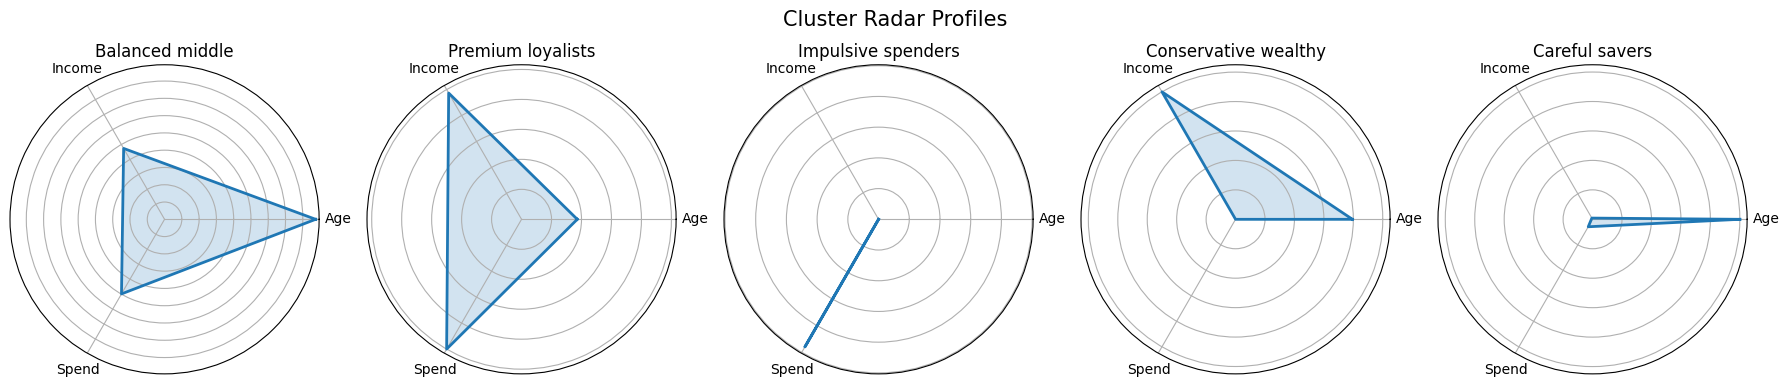

In [31]:
from math import pi

categories = ['Age', 'Income', 'Spend']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, axes = plt.subplots(1, 5, figsize=(18, 4), subplot_kw=dict(polar=True))

for i, (cluster_id, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    axes[i].plot(angles, values, linewidth=2)
    axes[i].fill(angles, values, alpha=0.2)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categories)
    axes[i].set_title(persona_map[cluster_id])
    axes[i].set_yticklabels([])

plt.suptitle('Cluster Radar Profiles', fontsize=15)
plt.tight_layout()
plt.show()

## Conclusion

- Both K-Means and Hierarchical Clustering identified **five customer segments**.
- Despite different cluster labels, both methods produced similar customer groupings.
- Customers were mainly segmented based on their **income and spending behavior**.
- The analysis revealed distinct groups such as high-income/high-spending, high-income/low-spending, low-income/high-spending, low-income/low-spending, and moderate customers.
- These insights can help businesses design targeted marketing and customer retention strategies.

# Business Recommendations

## Cluster Profiles & Recommended Strategies

### 1. Balanced Middle
- **Average Age:** 42.7 years
- **Average Income:** $55.3k
- **Average Spending Score:** 49.5

**Recommendation:** Encourage repeat purchases through loyalty programs and personalized offers.

---

### 2. Premium Loyalists
- **Average Age:** 32.7 years
- **Average Income:** $86.5k
- **Average Spending Score:** 82.1

**Recommendation:** Retain these high-value customers with VIP benefits, exclusive products, and premium services.

---

### 3. Impulsive Spenders
- **Average Age:** 25.3 years
- **Average Income:** $25.7k
- **Average Spending Score:** 79.4

**Recommendation:** Use flash sales, limited-time discounts, and trend-based marketing to drive purchases.

---

### 4. Conservative Wealthy
- **Average Age:** 41.1 years
- **Average Income:** $88.2k
- **Average Spending Score:** 17.1

**Recommendation:** Increase engagement through personalized recommendations and targeted promotions.

---

### 5. Careful Savers
- **Average Age:** 45.2 years
- **Average Income:** $26.3k
- **Average Spending Score:** 20.9

**Recommendation:** Focus on value-for-money products, discounts, and bundled offers.

In [32]:
import plotly.express as px

fig = px.scatter_3d(
    df_Kmeans,
    x='Age', y='Income(k$/yr)', z='SpendScore(1-100)',
    color='Persona',
    title='Customer Segments — 3D View (KMeans)',
    opacity=0.75,
    height=600
)
fig.update_traces(marker=dict(size=5))
fig.show()

# Save the Model

In [33]:
import joblib

## Save trained model
joblib.dump(KMeans_clusters, "../artifacts/model.pkl")

## Save scaler
joblib.dump(scaler, "../artifacts/scaler.pkl")

['../artifacts/scaler.pkl']